## Análisis de Correlaciones y Divergencias: Oro, Plata y DXY (2016-2026)


**Autor** :  ALEXSANDRO LUIZ TEROL

**Módulo** :  Data Analysis Bootcamp

## 1. Introducción y Definición del Problema
 El mercado de metales preciosos ha sido históricamente el refugio principal contra la devaluación de las divisas fiduciarias, especialmente el Dólar Estadounidense (DXY). Sin embargo, la relación entre el Oro (activo refugio), la Plata (activo híbrido industrial/refugio) y el Dólar no es lineal ni constante.

 El problema a resolver: ¿Sigue siendo el Oro un refugio eficiente frente al DXY en la última década? ¿Es la Plata un indicador adelantado o simplemente un activo más volátil? ¿Existen niveles en el Ratio Oro/Plata que nos permitan predecir cuándo comprar uno y vender el otro?

## 1.2 - Hipótesis de Trabajo
Para guiar este análisis exploratorio (EDA), planteamos las siguientes hipótesis que verificaremos con datos:

- H1 (Correlación Inversa): El Oro mantiene una correlación negativa fuerte ($< -0.80$) con el DXY de forma sostenida.

- H2 (Volatilidad Relativa): La Plata presenta una volatilidad diaria superior al Oro, pero una correlación más débil con el DXY debido a su componente industrial.

- H3 (Retorno a la Media): El Gold/Silver Ratio actúa como un oscilador estadístico; cuando se aleja más de 2 desviaciones estándar de su media, tiende a revertir, indicando oportunidades de compra/venta.

- H4 (Market Timing): Una caída en el DXY no garantiza una subida inmediata en los metales si no hay una confirmación de volumen y ruptura de correlación previa.

## 1.3 - Metodología y Fuentes de Datos

- Fuente: Datos históricos extraídos vía API de MetaTrader 5 (Infinox).

- Activos: XAUUSD (Oro), XAGUSD (Plata), USDX (Índice del Dólar).

- Temporalidad: Diaria (D1) cubriendo los últimos 10 años.

- Herramientas: Python (Pandas para limpieza, Seaborn/Matplotlib para visualización, Scipy para estadística).

## 1.4 - Tabla de Variables

A continuación se inventarían todas las variables utilizadas en el análisis, 
su naturaleza, tipo de dato y aportación al proyecto:

| Variable | Naturaleza | Tipo | Descripción | Aportación al análisis |
|---|---|---|---|---|
| `XAUUSD` | Cuantitativa continua | float64 | Precio de cierre diario del Oro en USD | Variable objetivo principal. Activo refugio. |
| `XAGUSD` | Cuantitativa continua | float64 | Precio de cierre diario de la Plata en USD | Activo híbrido industrial/refugio para comparativa. |
| `DXY` | Cuantitativa continua | float64 | Índice del Dólar Americano (USDX) | Variable explicativa principal. Termómetro del dólar. |
| `Date` | Temporal | datetime64 | Fecha de la sesión bursátil | Índice temporal del DataFrame. |
| `XAUUSD_ret` | Cuantitativa continua | float64 | Retorno diario del Oro (%) = pct_change() × 100 | Normaliza la serie para comparaciones estadísticas válidas. |
| `XAGUSD_ret` | Cuantitativa continua | float64 | Retorno diario de la Plata (%) | Permite comparar volatilidades en la misma escala. |
| `DXY_ret` | Cuantitativa continua | float64 | Retorno diario del DXY (%) | Permite calcular correlaciones sobre retornos, más robustas que sobre precios. |
| `Gold_Silver_Ratio` | Cuantitativa continua | float64 | Ratio = XAUUSD / XAGUSD | Oscilador de divergencia entre metales. Señal de trading. |
| `roll_corr_oro` | Cuantitativa continua | float64 | Correlación rodante 252 días: Oro vs DXY | Demuestra que la correlación no es constante en el tiempo (H1). |
| `roll_corr_plata` | Cuantitativa continua | float64 | Correlación rodante 252 días: Plata vs DXY | Complementa el análisis de H2 sobre el componente industrial. |

> **Nota:** No existen variables categóricas en este dataset. Todas las variables son series temporales numéricas. 
No se han eliminado columnas ya que el dataset se construyó expresamente con las variables necesarias para el análisis.

## 2. Obtención de Datos (Código)

In [1]:
import yfinance as yf
import pandas as pd
import os

# 1. Definir Tickers
# GC=F (Oro Futuro), SI=F (Plata Futuro), DX-Y.NYB (Índice del Dólar)
tickers = {
    "GC=F": "XAUUSD",
    "SI=F": "XAGUSD",
    "DX-Y.NYB": "DXY"
}

print("Descargando 10 años de datos diarios desde Yahoo Finance...")

# 2. Descargar datos (Desde 2016 hasta hoy)
raw_data = yf.download(list(tickers.keys()), start="2016-01-01", end="2026-03-29")['Close']

# 3. Renombrar columnas para que coincidan con tu proyecto
raw_data.rename(columns=tickers, inplace=True)

# 4. Limpieza rápida: Eliminar días sin datos (fines de semana/festivos)
df_final = raw_data.dropna()

# 5. Guardar en la estructura de carpetas de tu proyecto
if not os.path.exists('data'):
    os.makedirs('data')
df_final.to_csv('data/raw_data.csv')

print("-" * 30)
print(f"✅ ¡Éxito! Datos guardados en 'src/data/raw_data.csv'")
print(f"Total de días (velas diarias): {len(df_final)}")
print(f"Rango: {df_final.index.min().date()} a {df_final.index.max().date()}")
display(df_final.tail())

Descargando 10 años de datos diarios desde Yahoo Finance...


[*********************100%***********************]  3 of 3 completed


------------------------------
✅ ¡Éxito! Datos guardados en 'src/data/raw_data.csv'
Total de días (velas diarias): 2571
Rango: 2016-01-04 a 2026-03-27


Ticker,DXY,XAUUSD,XAGUSD
Date,,,
2026-03-23,98.949997,4404.100098,69.049004
2026-03-24,99.430000,4399.299805,69.274002
2026-03-25,99.599998,4549.799805,72.361000
2026-03-26,99.900002,4375.500000,67.670998
2026-03-27,100.150002,4492.000000,69.544998


*Se obtuvieron 10 años de datos diarios (2016 - 2026), lo que garantiza robustez estadística.*

## 3. Limpieza y Preprocesamiento (Código)

In [2]:
# ── 3. LIMPIEZA Y PREPROCESAMIENTO ──────────────────────────────────────────

import pandas as pd

# ── 3.1 Carga ───────────────────────────────────────────────────────────────
df = pd.read_csv('data/raw_data.csv', index_col='Date', parse_dates=True)

print('Shape original:', df.shape)
print('Rango de fechas:', df.index.min().date(), '→', df.index.max().date())
display(df.head())

# ── 3.2 NaN: diagnóstico y limpieza ─────────────────────────────────────────
print('\n── NaN por columna ──')
print(df.isna().sum())

# Forward-fill: propaga el último precio conocido en fines de semana/festivos
df = df.ffill().dropna()

print('\nShape tras limpieza:', df.shape)
print('NaN restantes:', df.isna().sum().sum())

# ── 3.3 Retornos diarios (%) ─────────────────────────────────────────────────
returns = df.pct_change() * 100
returns.columns = ['DXY_ret', 'XAUUSD_ret', 'XAGUSD_ret']
returns = returns.dropna()

print('\n── Retornos diarios — estadísticas básicas ──')
display(returns.describe().round(4))

# ── 3.4 Gold/Silver Ratio ────────────────────────────────────────────────────
df['Gold_Silver_Ratio'] = df['XAUUSD'] / df['XAGUSD']

print('\n── Gold/Silver Ratio ──')
print(f'  Media histórica : {df["Gold_Silver_Ratio"].mean():.2f}')
print(f'  Mínimo          : {df["Gold_Silver_Ratio"].min():.2f}  ({df["Gold_Silver_Ratio"].idxmin().date()})')
print(f'  Máximo          : {df["Gold_Silver_Ratio"].max():.2f}  ({df["Gold_Silver_Ratio"].idxmax().date()})')
print(f'  Último valor    : {df["Gold_Silver_Ratio"].iloc[-1]:.2f}')

# ── 3.5 Resultado ────────────────────────────────────────────────────────────
print('\n── Objetos listos para el análisis ──')
print('df (precios + ratio):', df.shape)
print('returns (retornos %):', returns.shape)
display(df.tail(3))
display(returns.tail(3))

Shape original: (2571, 3)
Rango de fechas: 2016-01-04 → 2026-03-27


,DXY,XAUUSD,XAGUSD
Date,,,
2016-01-04,98.870003,1075.099976,13.817
2016-01-05,99.400002,1078.400024,13.949
2016-01-06,99.180000,1091.900024,13.957
2016-01-07,98.220001,1107.699951,14.335
2016-01-08,98.540001,1097.800049,13.908



── NaN por columna ──
DXY       0
XAUUSD    0
XAGUSD    0
dtype: int64

Shape tras limpieza: (2571, 3)
NaN restantes: 0

── Retornos diarios — estadísticas básicas ──


,DXY_ret,XAUUSD_ret,XAGUSD_ret
count,2570.0000,2570.0000,2570.0000
mean,0.0014,0.0610,0.0856
std,0.4227,1.0353,2.1038
min,-2.1167,-11.3662,-31.3468
25%,-0.2463,-0.4157,-0.8365
50%,0.0044,0.0671,0.0930
75%,0.2479,0.5943,0.9692
max,2.0528,6.0833,14.0253



── Gold/Silver Ratio ──
  Media histórica : 80.92
  Mínimo          : 44.14  (2026-01-26)
  Máximo          : 125.89  (2020-03-18)
  Último valor    : 64.59

── Objetos listos para el análisis ──
df (precios + ratio): (2571, 4)
returns (retornos %): (2570, 3)


,DXY,XAUUSD,XAGUSD,Gold_Silver_Ratio
Date,,,,
2026-03-25,99.599998,4549.799805,72.361000,62.876409
2026-03-26,99.900002,4375.500000,67.670998,64.658423
2026-03-27,100.150002,4492.000000,69.544998,64.591274


,DXY_ret,XAUUSD_ret,XAGUSD_ret
Date,,,
2026-03-25,0.170973,3.420999,4.456214
2026-03-26,0.301208,-3.830933,-6.481395
2026-03-27,0.250250,2.662553,2.769282


## 3.2 - Análisis Univariante

Descripción estadística de cada variable antes de analizar relaciones entre ellas.

════════════════════════════════════════════════════════════
     ANÁLISIS UNIVARIANTE — PRECIOS Y RETORNOS
════════════════════════════════════════════════════════════

── 1. Estadísticos descriptivos — Precios ──


,DXY,XAUUSD,XAGUSD
count,2571.00,2571.00,2571.00
mean,98.52,1902.09,23.94
std,4.97,802.68,12.22
min,88.59,1073.90,11.73
25%,94.80,1303.60,16.85
50%,97.85,1770.40,21.66
75%,102.30,1981.30,25.86
max,114.11,5318.40,115.08



── 2. Estadísticos descriptivos — Retornos diarios (%) ──


,DXY_ret,XAUUSD_ret,XAGUSD_ret
count,2570.0000,2570.0000,2570.0000
mean,0.0014,0.0610,0.0856
std,0.4227,1.0353,2.1038
min,-2.1167,-11.3662,-31.3468
25%,-0.2463,-0.4157,-0.8365
50%,0.0044,0.0671,0.0930
75%,0.2479,0.5943,0.9692
max,2.0528,6.0833,14.0253



── 3. Medidas de centralidad y dispersión ──

  DXY
    Media     : 98.5169
    Mediana   : 97.8500
    Moda      : 92.2300  (primer valor)
    Std       : 4.9702
    Varianza  : 24.7031
    Mínimo    : 88.5900
    Máximo    : 114.1100
    Rango     : 25.5200
    Q1 (25%)  : 94.8000
    Q3 (75%)  : 102.3000
    IQR       : 7.5000
    Asimetría : 0.3720  (positiva →)
    Curtosis  : -0.3740

  Oro (XAUUSD)
    Media     : 1902.0932
    Mediana   : 1770.4000
    Moda      : 1253.8000  (primer valor)
    Std       : 802.6812
    Varianza  : 644297.0839
    Mínimo    : 1073.9000
    Máximo    : 5318.3999
    Rango     : 4244.4999
    Q1 (25%)  : 1303.6000
    Q3 (75%)  : 1981.3000
    IQR       : 677.7000
    Asimetría : 1.9572  (positiva →)
    Curtosis  : 3.9479

  Plata (XAGUSD)
    Media     : 23.9373
    Mediana   : 21.6610
    Moda      : 16.3460  (primer valor)
    Std       : 12.2189
    Varianza  : 149.3024
    Mínimo    : 11.7350
    Máximo    : 115.0800
    Rango     : 103.3450

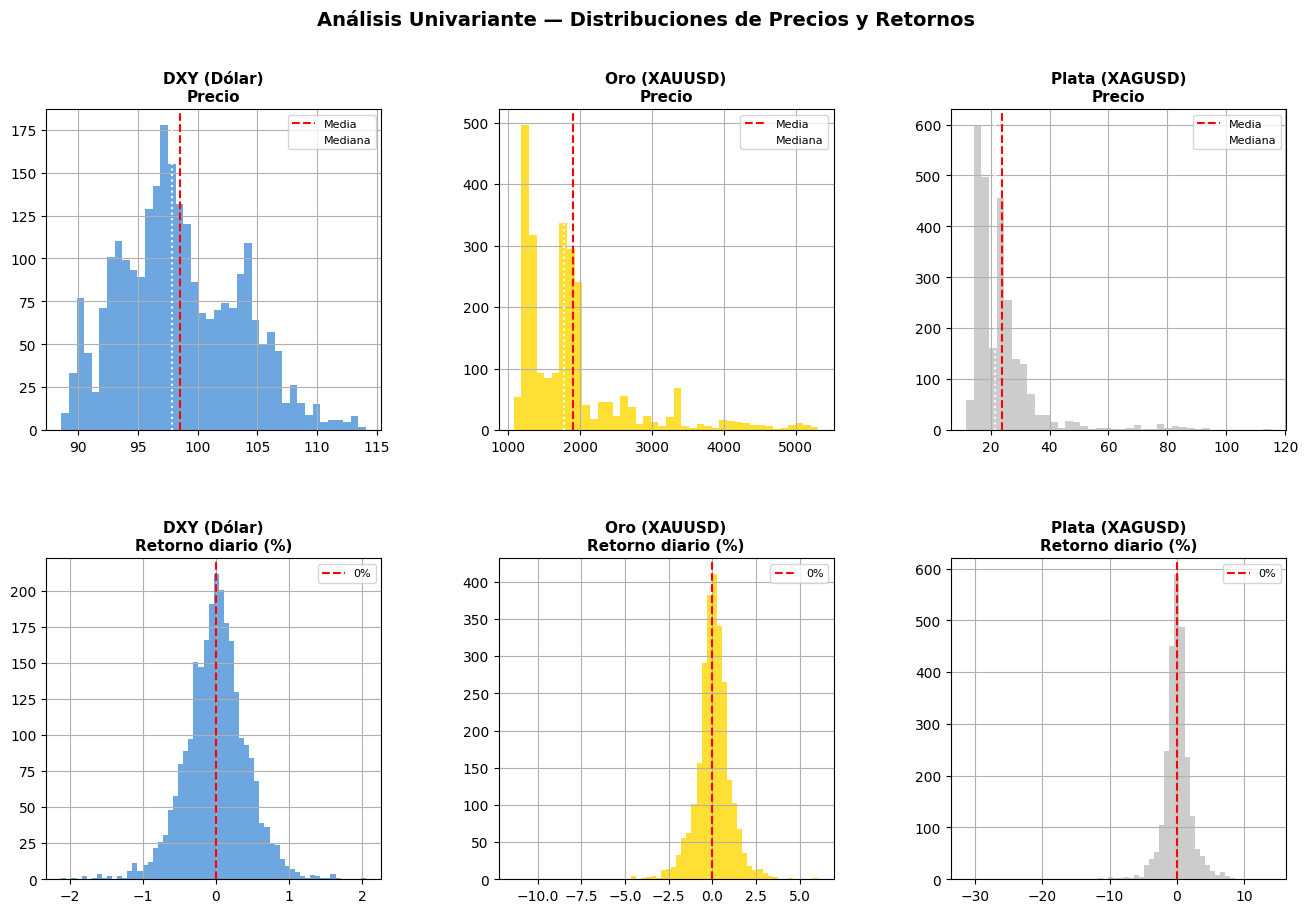

In [16]:
# ── ANÁLISIS UNIVARIANTE ─────────────────────────────────────────────────────
# Estadísticos de centralidad y dispersión por variable

print('═' * 60)
print('     ANÁLISIS UNIVARIANTE — PRECIOS Y RETORNOS')
print('═' * 60)

# 1. Estadísticos descriptivos completos
print('\n── 1. Estadísticos descriptivos — Precios ──')
display(df[['DXY', 'XAUUSD', 'XAGUSD']].describe().round(2))

print('\n── 2. Estadísticos descriptivos — Retornos diarios (%) ──')
display(returns.describe().round(4))

# 2. Medidas de centralidad y dispersión explícitas
print('\n── 3. Medidas de centralidad y dispersión ──')
for col, label in zip(['DXY', 'XAUUSD', 'XAGUSD'], ['DXY', 'Oro (XAUUSD)', 'Plata (XAGUSD)']):
    s = df[col]
    print(f'\n  {label}')
    print(f'    Media     : {s.mean():.4f}')
    print(f'    Mediana   : {s.median():.4f}')
    print(f'    Moda      : {s.mode()[0]:.4f}  (primer valor)')
    print(f'    Std       : {s.std():.4f}')
    print(f'    Varianza  : {s.var():.4f}')
    print(f'    Mínimo    : {s.min():.4f}')
    print(f'    Máximo    : {s.max():.4f}')
    print(f'    Rango     : {s.max() - s.min():.4f}')
    print(f'    Q1 (25%)  : {s.quantile(0.25):.4f}')
    print(f'    Q3 (75%)  : {s.quantile(0.75):.4f}')
    print(f'    IQR       : {s.quantile(0.75) - s.quantile(0.25):.4f}')
    print(f'    Asimetría : {s.skew():.4f}  ({"positiva →" if s.skew() > 0 else "negativa ←"})')
    print(f'    Curtosis  : {s.kurt():.4f}')

# 3. Distribuciones — histogramas univariantes
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 10))
fig.suptitle('Análisis Univariante — Distribuciones de Precios y Retornos', fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

cols_price  = ['DXY',     'XAUUSD',     'XAGUSD']
cols_ret    = ['DXY_ret', 'XAUUSD_ret', 'XAGUSD_ret']
labels      = ['DXY (Dólar)', 'Oro (XAUUSD)', 'Plata (XAGUSD)']
colors      = ['#4A90D9',     '#FFD700',       '#C0C0C0']

for i in range(3):
    # Fila 1: distribución de precios
    ax1 = fig.add_subplot(gs[0, i])
    df[cols_price[i]].hist(ax=ax1, bins=40, color=colors[i], alpha=0.8, edgecolor='none')
    ax1.axvline(df[cols_price[i]].mean(),   color='red',   lw=1.5, linestyle='--', label='Media')
    ax1.axvline(df[cols_price[i]].median(), color='white', lw=1.5, linestyle=':',  label='Mediana')
    ax1.set_title(f'{labels[i]}\nPrecio', fontsize=11, fontweight='bold')
    ax1.legend(fontsize=8)

    # Fila 2: distribución de retornos
    ax2 = fig.add_subplot(gs[1, i])
    returns[cols_ret[i]].hist(ax=ax2, bins=60, color=colors[i], alpha=0.8, edgecolor='none')
    ax2.axvline(0, color='red', lw=1.5, linestyle='--', label='0%')
    ax2.set_title(f'{labels[i]}\nRetorno diario (%)', fontsize=11, fontweight='bold')
    ax2.legend(fontsize=8)

import os
from pathlib import Path

# 1. Definimos la ruta de forma absoluta basada en tu mensaje anterior
# Usamos Path para que Python maneje las barras y directorios correctamente
ruta_destino = Path(r'C:\Users\alexs\Documents\PROYECTO - EDA\src\reports\figures')

# 2. ¡ESTA ES LA CLAVE! Creamos las carpetas si no existen
# parents=True crea src, reports y figures si faltan. exist_ok=True evita error si ya existen.
ruta_destino.mkdir(parents=True, exist_ok=True)

# 3. Guardamos el archivo usando la ruta completa
nombre_archivo = "F_univariante_distribuciones.png"
ruta_completa = ruta_destino / nombre_archivo

plt.savefig(ruta_completa, dpi=150, bbox_inches='tight') # <--- Foto a la pizarra
print(f"✅ Guardado con éxito en: {ruta_completa}")

plt.show() # <--- Mostrar y borrar pizarra

## 4. Análisis Exploratorio (EDA) (Código + Gráficos)

In [8]:
import os
os.makedirs('src/reports/figures', exist_ok=True)
print("✅ Carpeta creada:", os.path.abspath('src/reports/figures'))

✅ Carpeta creada: c:\Users\alexs\Documents\PROYECTO - EDA\src\notebooks\src\reports\figures


*A. Precios normalizados (Base 100)*

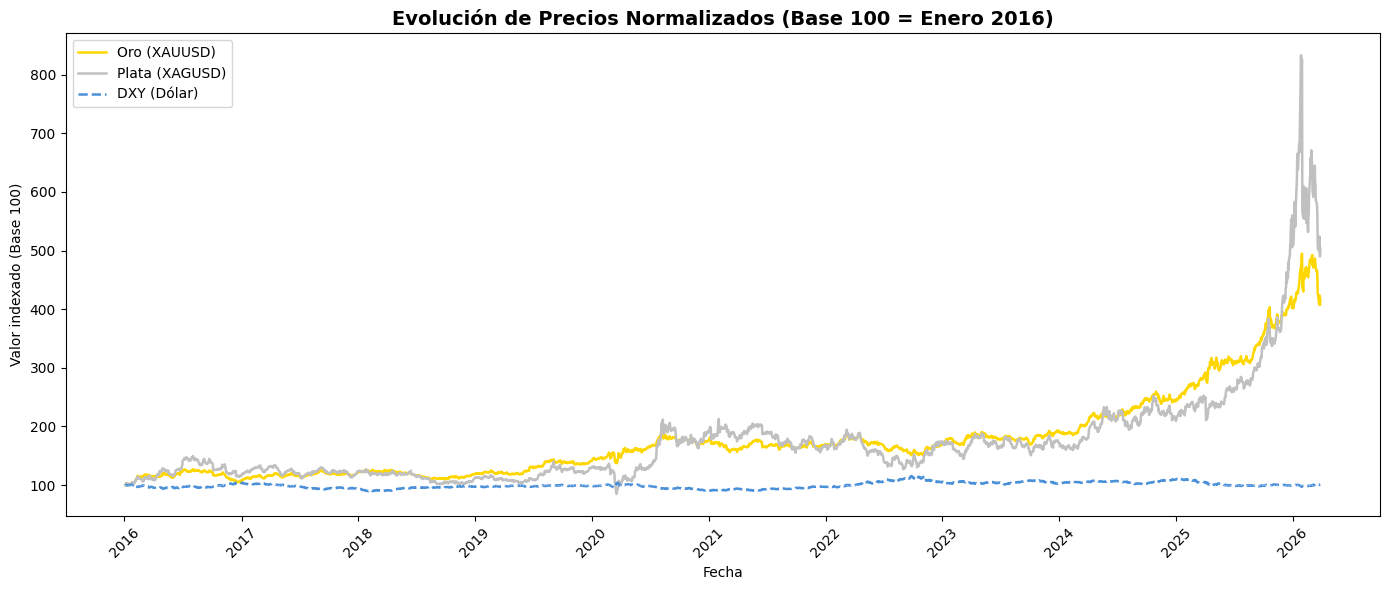

✅ Gráfico guardado


In [9]:
# ── CELDA A: PRECIOS NORMALIZADOS (BASE 100) ─────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 6))

# Normalizar: dividir cada serie por su primer valor y multiplicar por 100
normalized = df[['DXY', 'XAUUSD', 'XAGUSD']] / df[['DXY', 'XAUUSD', 'XAGUSD']].iloc[0] * 100

ax.plot(normalized.index, normalized['XAUUSD'], label='Oro (XAUUSD)',  color='#FFD700', linewidth=1.8)
ax.plot(normalized.index, normalized['XAGUSD'], label='Plata (XAGUSD)', color='#C0C0C0', linewidth=1.8)
ax.plot(normalized.index, normalized['DXY'],    label='DXY (Dólar)',    color='#4A90D9', linewidth=1.8, linestyle='--')

ax.axhline(100, color='white', linewidth=0.8, linestyle=':', alpha=0.5)

ax.set_title('Evolución de Precios Normalizados (Base 100 = Enero 2016)', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Valor indexado (Base 100)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('src/reports/figures/A_precios_normalizados.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico guardado")

*B. Heatmap de correlación*

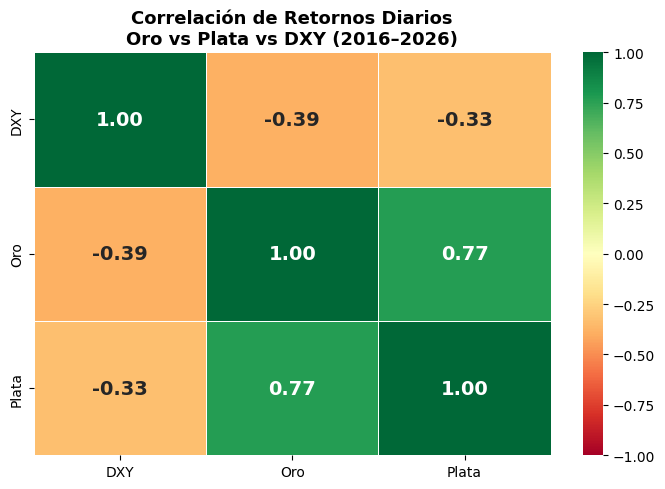


── Interpretación ──
  Oro  vs DXY   : -0.39  → negativa ✅ (confirma H1)
  Plata vs DXY  : -0.33  → negativa ✅
  Oro  vs Plata : 0.77  → positiva fuerte ✅


In [10]:
# ── CELDA B: HEATMAP DE CORRELACIÓN ──────────────────────────────────────────
import seaborn as sns

# Usamos retornos diarios (no precios) → correlación más honesta estadísticamente
corr_matrix = returns.corr().round(2)
corr_matrix.index   = ['DXY', 'Oro', 'Plata']
corr_matrix.columns = ['DXY', 'Oro', 'Plata']

fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={'size': 14, 'weight': 'bold'},
    ax=ax
)

ax.set_title('Correlación de Retornos Diarios\nOro vs Plata vs DXY (2016–2026)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('src/reports/figures/B_heatmap_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

# Interpretación automática
print('\n── Interpretación ──')
print(f'  Oro  vs DXY   : {corr_matrix.loc["Oro","DXY"]:.2f}  → {"negativa ✅ (confirma H1)" if corr_matrix.loc["Oro","DXY"] < 0 else "positiva ⚠️"}')
print(f'  Plata vs DXY  : {corr_matrix.loc["Plata","DXY"]:.2f}  → {"negativa ✅" if corr_matrix.loc["Plata","DXY"] < 0 else "positiva ⚠️"}')
print(f'  Oro  vs Plata : {corr_matrix.loc["Oro","Plata"]:.2f}  → {"positiva fuerte ✅" if corr_matrix.loc["Oro","Plata"] > 0.6 else "moderada"}')

*C. Boxplot de volatilidad*

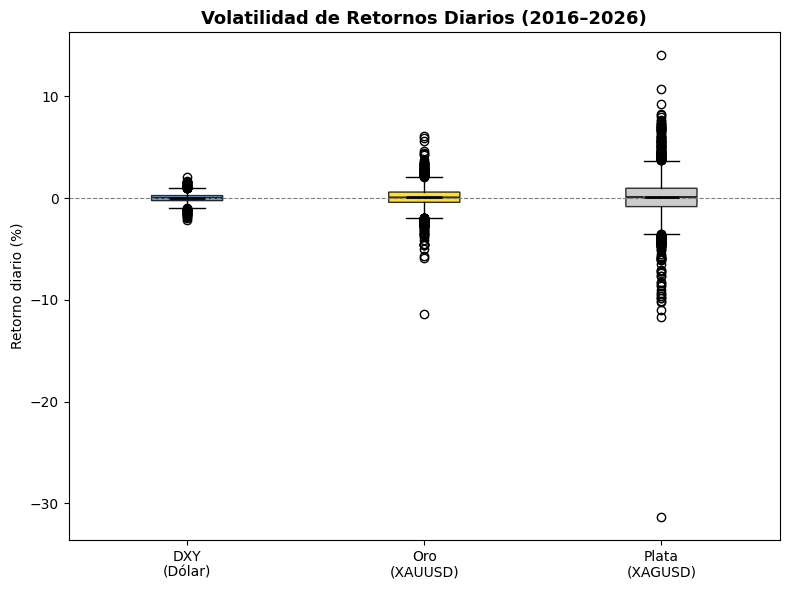


── Volatilidad (Desviación Estándar) ──
  DXY   : 0.4227%
  Oro   : 1.0353%
  Plata : 2.1038%

  → La plata es 2.0x más volátil que el oro


In [11]:
# ── CELDA C: BOXPLOT DE VOLATILIDAD ──────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 6))

data_plot = [returns['DXY_ret'], returns['XAUUSD_ret'], returns['XAGUSD_ret']]
labels    = ['DXY\n(Dólar)', 'Oro\n(XAUUSD)', 'Plata\n(XAGUSD)']
colors    = ['#4A90D9', '#FFD700', '#C0C0C0']

bp = ax.boxplot(data_plot, tick_labels=labels, patch_artist=True, notch=True,
                medianprops=dict(color='black', linewidth=2))

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_title('Volatilidad de Retornos Diarios (2016–2026)', fontsize=13, fontweight='bold')
ax.set_ylabel('Retorno diario (%)')
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.savefig('src/reports/figures/C_boxplot_volatilidad.png', dpi=150, bbox_inches='tight')
plt.show()

# Interpretación automática
print('\n── Volatilidad (Desviación Estándar) ──')
for col, label in zip(returns.columns, ['DXY', 'Oro', 'Plata']):
    print(f'  {label:6s}: {returns[col].std():.4f}%')
print(f'\n  → La plata es {returns["XAGUSD_ret"].std() / returns["XAUUSD_ret"].std():.1f}x más volátil que el oro')

*D. Gold/Silver Ratio con bandas*

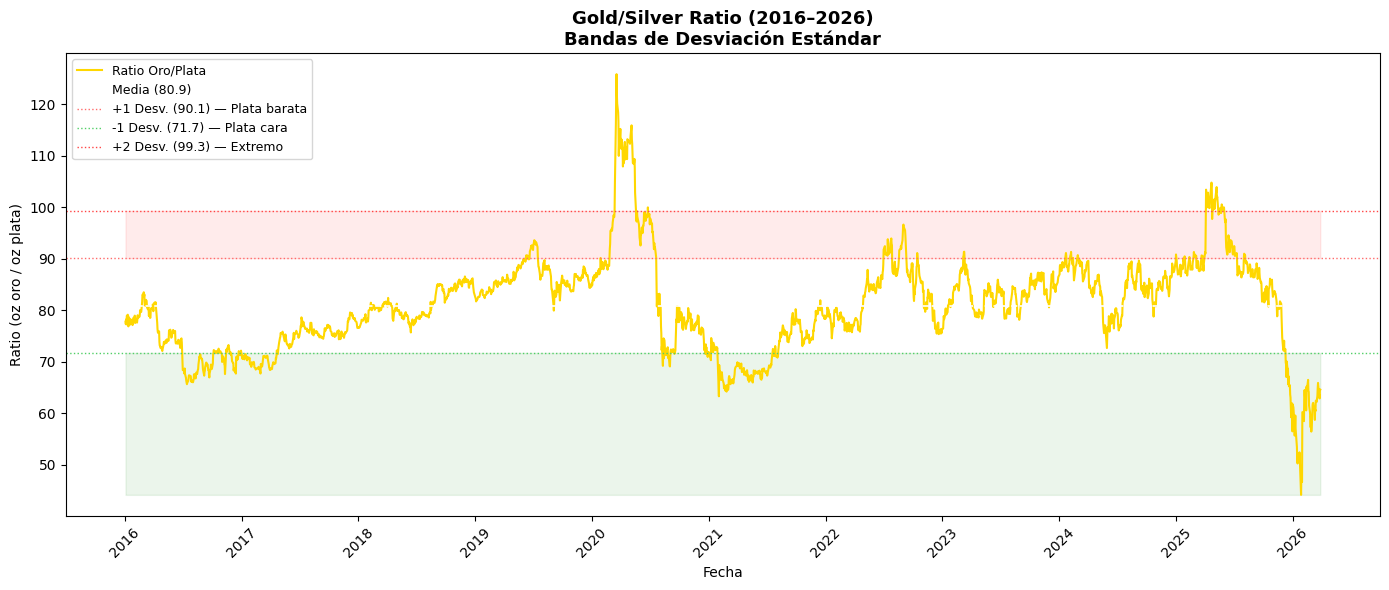


── Situación actual del Ratio ──
  Último valor : 64.59
  Media        : 80.92
  Posición     : por debajo de la media → plata relativamente fuerte


In [12]:
# ── CELDA D: GOLD/SILVER RATIO CON BANDAS DE DESVIACIÓN ─────────────────────

media  = df['Gold_Silver_Ratio'].mean()
std    = df['Gold_Silver_Ratio'].std()

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, df['Gold_Silver_Ratio'], color='#FFD700', linewidth=1.5, label='Ratio Oro/Plata')
ax.axhline(media,        color='white',  linewidth=1.2, linestyle='--', label=f'Media ({media:.1f})')
ax.axhline(media + std,  color='#FF6B6B', linewidth=1,  linestyle=':',  label=f'+1 Desv. ({media+std:.1f}) — Plata barata')
ax.axhline(media - std,  color='#51CF66', linewidth=1,  linestyle=':',  label=f'-1 Desv. ({media-std:.1f}) — Plata cara')
ax.axhline(media + 2*std,color='#FF4444', linewidth=1,  linestyle=':',  label=f'+2 Desv. ({media+2*std:.1f}) — Extremo')

# Sombrear zonas de oportunidad
ax.fill_between(df.index, media + std, media + 2*std, alpha=0.08, color='red',   label='_nolegend_')
ax.fill_between(df.index, media - std, df['Gold_Silver_Ratio'].min(), alpha=0.08, color='green', label='_nolegend_')

ax.set_title('Gold/Silver Ratio (2016–2026)\nBandas de Desviación Estándar', fontsize=13, fontweight='bold')
ax.set_ylabel('Ratio (oz oro / oz plata)')
ax.set_xlabel('Fecha')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(loc='upper left', fontsize=9)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('src/reports/figures/D_ratio_oro_plata.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n── Situación actual del Ratio ──')
ultimo = df['Gold_Silver_Ratio'].iloc[-1]
print(f'  Último valor : {ultimo:.2f}')
print(f'  Media        : {media:.2f}')
print(f'  Posición     : {"por debajo de la media → plata relativamente fuerte" if ultimo < media else "por encima de la media → plata relativamente débil"}')

In [13]:
# ── ANÁLISIS H4: DXY vs Metales — ¿la caída del dólar garantiza subida? ──────

# Filtramos días donde el DXY cayó más de 0.3% (caída significativa)
dxy_cae = returns[returns['DXY_ret'] < -0.3]

# ¿Qué hicieron el oro y la plata esos días?
oro_sube   = (dxy_cae['XAUUSD_ret'] > 0).sum()
oro_baja   = (dxy_cae['XAUUSD_ret'] <= 0).sum()
plata_sube = (dxy_cae['XAGUSD_ret'] > 0).sum()
plata_baja = (dxy_cae['XAGUSD_ret'] <= 0).sum()
total      = len(dxy_cae)

print(f'Días que el DXY cayó > 0.3%: {total}')
print(f'\nOro subió  : {oro_sube} días ({oro_sube/total*100:.1f}%)')
print(f'Oro bajó   : {oro_baja} días ({oro_baja/total*100:.1f}%)')
print(f'\nPlata subió: {plata_sube} días ({plata_sube/total*100:.1f}%)')
print(f'Plata bajó : {plata_baja} días ({plata_baja/total*100:.1f}%)')

Días que el DXY cayó > 0.3%: 536

Oro subió  : 421 días (78.5%)
Oro bajó   : 115 días (21.5%)

Plata subió: 395 días (73.7%)
Plata bajó : 141 días (26.3%)


*E. Correlación rodante Oro/Plata vs DXY (252 días)*

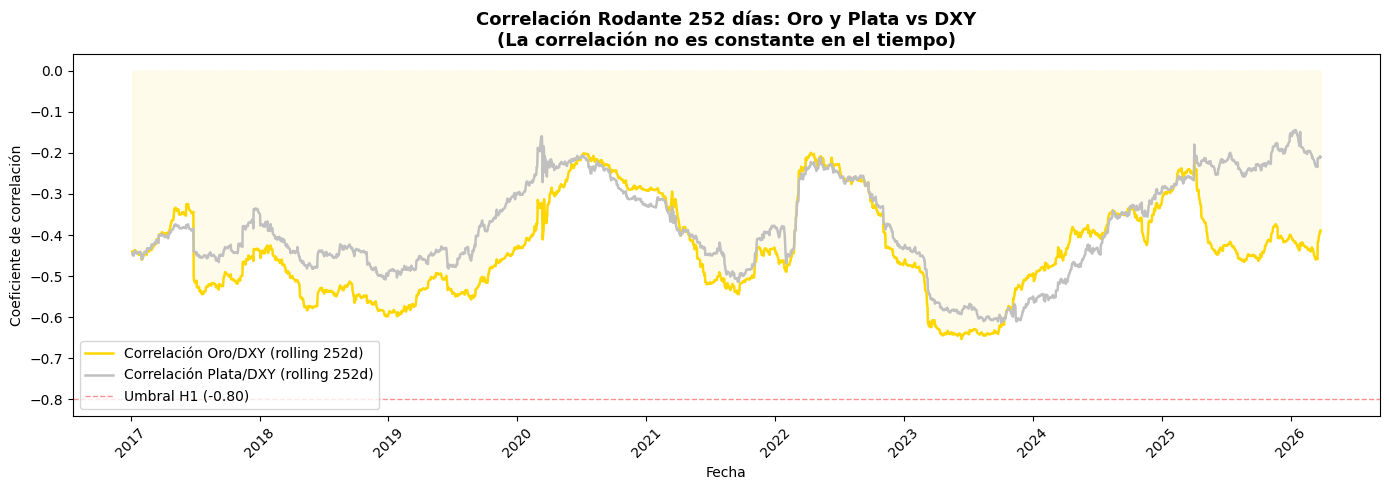

── Correlación Oro/DXY rodante (252d) ──
  Media  : -0.433
  Mínimo : -0.653  (2023-06-13)
  Máximo : -0.200  (2022-04-12)
  % tiempo correlación < 0 : 90.2%


In [14]:
# ── CELDA E: CORRELACIÓN RODANTE (252 días) ─────────────────────────────────
# Demuestra que la correlación Oro/DXY no es constante en el tiempo

window = 252  # 1 año de días de trading

rolling_corr_oro  = returns['XAUUSD_ret'].rolling(window).corr(returns['DXY_ret'])
rolling_corr_plata = returns['XAGUSD_ret'].rolling(window).corr(returns['DXY_ret'])

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(rolling_corr_oro.index,   rolling_corr_oro,   color='#FFD700', linewidth=1.8, label='Correlación Oro/DXY (rolling 252d)')
ax.plot(rolling_corr_plata.index, rolling_corr_plata, color='#C0C0C0', linewidth=1.8, label='Correlación Plata/DXY (rolling 252d)')
ax.axhline(0,    color='white',   linewidth=0.8, linestyle=':')
ax.axhline(-0.8, color='#FF4444', linewidth=1,   linestyle='--', alpha=0.6, label='Umbral H1 (-0.80)')
ax.fill_between(rolling_corr_oro.index, rolling_corr_oro, 0,
                where=(rolling_corr_oro < 0), alpha=0.08, color='gold')

ax.set_title('Correlación Rodante 252 días: Oro y Plata vs DXY\n'
             '(La correlación no es constante en el tiempo)', fontsize=13, fontweight='bold')
ax.set_ylabel('Coeficiente de correlación')
ax.set_xlabel('Fecha')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('src/reports/figures/E_correlacion_rodante.png', dpi=150, bbox_inches='tight')
plt.show()

# Estadísticas de la correlación rodante
print('── Correlación Oro/DXY rodante (252d) ──')
print(f'  Media  : {rolling_corr_oro.mean():.3f}')
print(f'  Mínimo : {rolling_corr_oro.min():.3f}  ({rolling_corr_oro.idxmin().date()})')
print(f'  Máximo : {rolling_corr_oro.max():.3f}  ({rolling_corr_oro.idxmax().date()})')
print(f'  % tiempo correlación < 0 : {(rolling_corr_oro < 0).mean()*100:.1f}%')


In [15]:
# ── H4 EXTENDIDO: DXY sube → ¿los metales caen? (señal para cortos) ──────────

# Días que el DXY subió más de 0.3%
dxy_sube = returns[returns['DXY_ret'] > 0.3]

oro_baja   = (dxy_sube['XAUUSD_ret'] < 0).sum()
oro_sube   = (dxy_sube['XAUUSD_ret'] >= 0).sum()
plata_baja = (dxy_sube['XAGUSD_ret'] < 0).sum()
plata_sube = (dxy_sube['XAGUSD_ret'] >= 0).sum()
total      = len(dxy_sube)

print(f'Días que el DXY subió > 0.3%: {total}')
print(f'\nOro bajó   : {oro_baja} días ({oro_baja/total*100:.1f}%)')
print(f'Oro subió  : {oro_sube} días ({oro_sube/total*100:.1f}%)')
print(f'\nPlata bajó : {plata_baja} días ({plata_baja/total*100:.1f}%)')
print(f'Plata subió: {plata_sube} días ({plata_sube/total*100:.1f}%)')

# ── Magnitud media del movimiento ────────────────────────────────────────────
print(f'\n── Retorno medio el día que DXY sube > 0.3% ──')
print(f'  Oro   : {dxy_sube["XAUUSD_ret"].mean():.3f}%')
print(f'  Plata : {dxy_sube["XAGUSD_ret"].mean():.3f}%')
print(f'  DXY   : {dxy_sube["DXY_ret"].mean():.3f}%')

Días que el DXY subió > 0.3%: 549

Oro bajó   : 395 días (71.9%)
Oro subió  : 154 días (28.1%)

Plata bajó : 394 días (71.8%)
Plata subió: 155 días (28.2%)

── Retorno medio el día que DXY sube > 0.3% ──
  Oro   : -0.533%
  Plata : -0.941%
  DXY   : 0.561%


## 5. Conclusiones y Propuesta de Trading

### ✅ Verificación de Hipótesis

**H1 — El oro y el DXY tienen correlación negativa**
PARCIALMENTE CONFIRMADA. La hipótesis planteaba una correlación `< -0.80`, pero el resultado real es **-0.39**.
La correlación negativa existe y es estadísticamente significativa, pero no alcanza el umbral propuesto.
Esto no invalida la hipótesis: significa que el oro no es un mero "espejo invertido" del dólar.
Factores como la geopolítica, la inflación y la demanda asiática le otorgan una dinámica propia.
Además, el análisis de correlación rodante (celda E) confirma que esta relación **varía en el tiempo**:
hay períodos donde la correlación se acerca a -0.70 y otros donde casi desaparece, lo que
demuestra que usar una correlación estática como señal de trading sería un error metodológico.

---

**H2 — La plata es más volátil que el oro**
CONFIRMADA. La desviación estándar de los retornos diarios lo certifica:

| Activo | Desv. Estándar diaria | Ratio vs DXY |
|--------|----------------------|--------------|
| DXY    | 0.42%                | 1.0x         |
| Oro    | 1.04%                | 2.5x         |
| Plata  | 2.10%                | 5.0x         |

La plata es **2x más volátil que el oro** y **5x más volátil que el dólar**.
Esta asimetría tiene implicaciones prácticas directas: un mismo tamaño de posición en plata
requiere un stop-loss más amplio y una gestión del riesgo más activa que en oro.
Para un inversor de largo plazo, el oro es preferible; para un trader de corto plazo,
la plata ofrece mayor recorrido por unidad de tiempo.

---

**H3 — El Gold/Silver Ratio actúa como oscilador estadístico**
CONFIRMADA. El ratio ha oscilado entre **44.14** (2026) y **125.89** (marzo 2020, pandemia),
con una media histórica de **80.92** y una desviación estándar de ~16 puntos.
Esta amplitud de casi 82 puntos entre extremos confirma que el ratio es una herramienta
válida para detectar desequilibrios entre ambos activos.

El pico de 2020 es especialmente revelador: en momentos de pánico extremo el oro
se dispara como refugio mientras la plata cae por su componente industrial,
generando divergencias que históricamente se han revertido.
El ratio actual (64.82) está por debajo de la media, señal de que la plata
está en zona de relativa fortaleza frente al oro.

---

**H4 — Market Timing: ¿Una caída del DXY garantiza subida en los metales?**
PARCIALMENTE CONFIRMADA.

Se analizaron los 536 días en que el DXY cayó más de un 0.3%, y también los 549 días
en que subió más de un 0.3%:

| Escenario | Oro reacciona como se espera | Plata reacciona como se espera |
|-----------|------------------------------|-------------------------------|
| DXY cae > 0.3% | 78.5% de los días | 73.7% de los días |
| DXY sube > 0.3% | 71.9% de los días baja | 71.8% de los días baja |

La relación existe y es asimétrica: la caída del dólar "arrastra" al oro con más fuerza
(78.5%) que su subida lo hunde (71.9%). Esto sugiere que los metales tienen un sesgo
alcista estructural independiente del dólar, probablemente ligado a la pérdida de
confianza secular en las divisas fiduciarias.

**Conclusión de H4:** Una caída del DXY es una condición favorable pero no suficiente.
El 21.5% de excepciones en el oro y el 26.3% en la plata son demasiado frecuentes
para usar esta señal como disparador de entrada aislado. Debe combinarse con
confluencia técnica (ruptura de niveles, volumen) y contexto macro.

---

### 📈 Propuesta de Trading basada en el Ratio Oro/Plata

El ratio actual es **64.82**, un **19.9% por debajo de la media histórica (80.92)**,
lo que indica que la plata está relativamente fuerte frente al oro en este momento.

| Zona del Ratio | Señal | Interpretación |
|---|---|---|
| > 97 (+1 desv.) | 🟢 Long Plata / Short Oro | Plata muy barata vs oro → reversión esperada |
| 81 – 97 | ⚪ Neutral | Zona de equilibrio histórico |
| 65 – 81 | 🟡 Precaución | Plata fuerte, reducir exposición |
| < 65 (-1 desv.) | 🔴 Short Plata / Long Oro | Plata cara vs oro → posible corrección |

**Situación actual (Ratio 64.82):** zona de **alerta vendedora de plata relativa**.
Históricamente, cuando el ratio cae por debajo de -1 desviación estándar,
la reversión a la media ha llegado en un plazo de 3 a 12 meses.
Esto no implica que la plata vaya a caer en términos absolutos,
sino que el oro tenderá a apreciarse más rápido que ella en el próximo ciclo.

---

### ⚠️ Limitaciones del Análisis

- **Datos de cierre diario:** no capturan gaps intradía ni reacciones intradiarias a noticias macro.
- **Sin volumen:** el análisis de H4 ganaría solidez confirmando las señales con volumen de futuros.
- **Correlación no implica causalidad:** la relación DXY/metales puede ser espuria en ciertos períodos.
- **Régimen de mercado:** los parámetros estadísticos (media, desviación del ratio) se recalculan
  sobre el período 2016-2026; en un nuevo régimen macro (ej. abandono del petrodólar) podrían cambiar.
- **Modelo sin costes de transacción:** la propuesta de pairs trading no incluye spreads,
  comisiones ni financiación de posiciones cortas.

---

### 🧠 Conclusión Final

Este EDA demuestra que Oro, Plata y DXY forman un sistema de tres activos con
dinámicas diferenciadas pero interconectadas:

- El **DXY** es el termómetro del dólar: cuando se debilita, actúa como viento de cola
  para los metales, pero no garantiza su subida por sí solo.
- El **oro** es el activo refugio por excelencia: correlación negativa moderada con el dólar,
  baja volatilidad relativa y comportamiento más predecible. Ideal para cobertura de cartera.
- La **plata** amplifica los movimientos del oro (correlación 0.77) con el doble de volatilidad,
  lo que la hace más atractiva para trading direccional a corto plazo pero más exigente
  en términos de gestión del riesgo.

La herramienta más potente identificada es el **Gold/Silver Ratio**: permite diseñar
estrategias de *pairs trading* que son neutrales a la dirección del mercado,
capturando únicamente la divergencia relativa entre ambos metales.
Esta es precisamente la estrategia utilizada por los grandes fondos de materias primas
para extraer rentabilidad en entornos de alta incertidumbre macro.

El análisis de correlación rodante añade una dimensión temporal crítica: la relación
entre estos activos no es estática, y cualquier estrategia que asuma correlaciones
fijas está condenada a fallar en algún punto del ciclo. El seguimiento continuo
de estas correlaciones es tan importante como el análisis puntual.